In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import SelectPercentile , chi2
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression ,SGDClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

from scipy.sparse import csr_matrix
from scipy.sparse import hstack
pd.set_option('display.max_rows',100)

# Loading Datasets

In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# ORIGINAL WORK

## EDA (Exploratory Data Analysis)

In [4]:
Train = train.copy()
Test = test.copy()
print(Train.shape)
print(Test.shape)

(198000, 15)
(102000, 14)


In [5]:
# filtering smaller comments from the training data

Train['comment_length'] = Train['comment'].str.len()
train_less_than_6 = Train[Train['comment_length'] < 6]
Train = Train[Train['comment_length'] > 5]
print(pd.DataFrame(train_less_than_6['comment'].head(10)))
print("")
print(f'dropping length:',len(train_less_than_6['comment']))

     comment
95     Troll
1096   B..S.
1398   BLM's
1665    amne
2943   Liar.
3822    Cuba
4070       a
4271     :-)
4510    Npoe
4574   rWong

dropping length: 259


## CHECKING FOR DATATYPES

In [6]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197740 entries, 0 to 197999
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   created_date    197740 non-null  object 
 1   post_id         197740 non-null  int64  
 2   emoticon_1      197740 non-null  int64  
 3   emoticon_2      197740 non-null  int64  
 4   emoticon_3      197740 non-null  int64  
 5   upvote          197740 non-null  int64  
 6   downvote        197740 non-null  int64  
 7   if_1            197740 non-null  int64  
 8   if_2            197740 non-null  int64  
 9   race            52539 non-null   object 
 10  religion        52539 non-null   object 
 11  gender          52539 non-null   object 
 12  disability      197740 non-null  bool   
 13  comment         197740 non-null  object 
 14  label           197740 non-null  int64  
 15  comment_length  197740 non-null  float64
dtypes: bool(1), float64(1), int64(9), object(5)
memory usage: 24.

In [7]:
Train.shape # 1 new column added "comment_length"

(197740, 16)

In [8]:
Train.head(2)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,comment_length
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2,118.0
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0,644.0


In [9]:
Test.head(2)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel


### Descriptive statistics of Numerical columns

In [10]:
Train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label,comment_length
count,197740.000000,197740.000000,197740.000000,197740.000000,197740.000000,197740.000000,197740.000000,197740.000000,197740.000000,197740.000000
mean,68.450415,0.279903,0.048372,0.121134,2.610054,0.666972,1.907854,7.959002,0.794634,303.302407
std,27.948456,1.023594,0.258568,0.481128,5.056977,2.045362,25.652498,14.848728,0.979950,266.396138
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,6.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,102.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,211.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000,419.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000,1892.000000


In [11]:
Test.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


### CHECKING FOR OUTLIERS

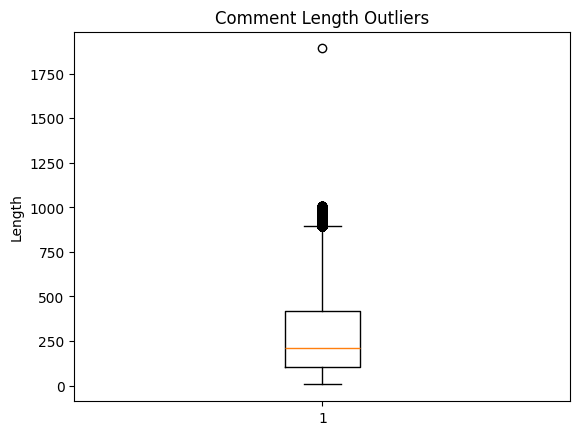

In [12]:
plt.boxplot(Train['comment_length']) # seeing only for comment 
plt.title("Comment Length Outliers")
plt.ylabel("Length")
plt.show()

- The boxplot shows that most comments are within a reasonable length, with a few extreme long comments.
- Very long comments may treated as outliers , but they aren't removed by me, because they may contain information for prediction

In [13]:
Train['Total_emoticons'] = Train['emoticon_1'] + Train['emoticon_2'] + Train['emoticon_3']
Test['Total_emoticons'] = Test['emoticon_1'] + Test['emoticon_2'] + Test['emoticon_3']

In [14]:
Train = Train.drop(['created_date','comment_length'],axis=1)
Test = Test.drop(['created_date'],axis=1)

In [15]:
Train.head(2)

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,Total_emoticons
0,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2,0
1,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0,0


In [16]:
Test.head(2)

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,Total_emoticons
0,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...,2
1,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel,0


### Checking Missing values

In [17]:
Train.isna().sum()

post_id                 0
emoticon_1              0
emoticon_2              0
emoticon_3              0
upvote                  0
downvote                0
if_1                    0
if_2                    0
race               145201
religion           145201
gender             145201
disability              0
comment                 0
label                   0
Total_emoticons         0
dtype: int64

In [18]:
Test.isna().sum()

post_id                0
emoticon_1             0
emoticon_2             0
emoticon_3             0
upvote                 0
downvote               0
if_1                   0
if_2                   0
race               75269
religion           75269
gender             75269
disability             0
comment                0
Total_emoticons        0
dtype: int64

### Filling missing values

* Filling the missing values in the dataset is must, otherwise models won't run

In [19]:
Train.fillna('',inplace = True) # replacing NaN with ''(empty string)
Test.fillna('',inplace = True)

In [20]:
print("'TRAIN'")
print("")
print(f"Train[race]    :",Train['race'].unique())
print(f"Train[religion]:",Train['religion'].unique())
print(f"Train[gender]  :",Train['gender'].unique())

print("") 

print("'TEST'")
print("")
print(f"Test[race]    :",Test['race'].unique())
print(f"Test[religion]:",Test['religion'].unique())
print(f"Test[gender]  :",Test['gender'].unique())

'TRAIN'

Train[race]    : ['' 'none' 'white' 'other' 'asian' 'black' 'latino']
Train[religion]: ['' 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']
Train[gender]  : ['' 'none' 'male' 'female' 'transgender' 'other']

'TEST'

Test[race]    : ['' 'black' 'other' 'none' 'asian' 'white' 'latino']
Test[religion]: ['' 'none' 'buddhist' 'atheist' 'muslim' 'christian' 'other' 'jewish'
 'hindu']
Test[gender]  : ['' 'male' 'none' 'female' 'transgender' 'other']


In [21]:
Train.replace('none','',inplace = True) # replacing 'none' with '' 
Test.replace('none','',inplace = True)

In [22]:
print(Train.isna().sum())
print("-"*70)
print(Test.isna().sum())

post_id            0
emoticon_1         0
emoticon_2         0
emoticon_3         0
upvote             0
downvote           0
if_1               0
if_2               0
race               0
religion           0
gender             0
disability         0
comment            0
label              0
Total_emoticons    0
dtype: int64
----------------------------------------------------------------------
post_id            0
emoticon_1         0
emoticon_2         0
emoticon_3         0
upvote             0
downvote           0
if_1               0
if_2               0
race               0
religion           0
gender             0
disability         0
comment            0
Total_emoticons    0
dtype: int64


### Correlation

* Correlation plot is very helpful in identifying which features in the dataset are more related to "label" feature that we want to predict.

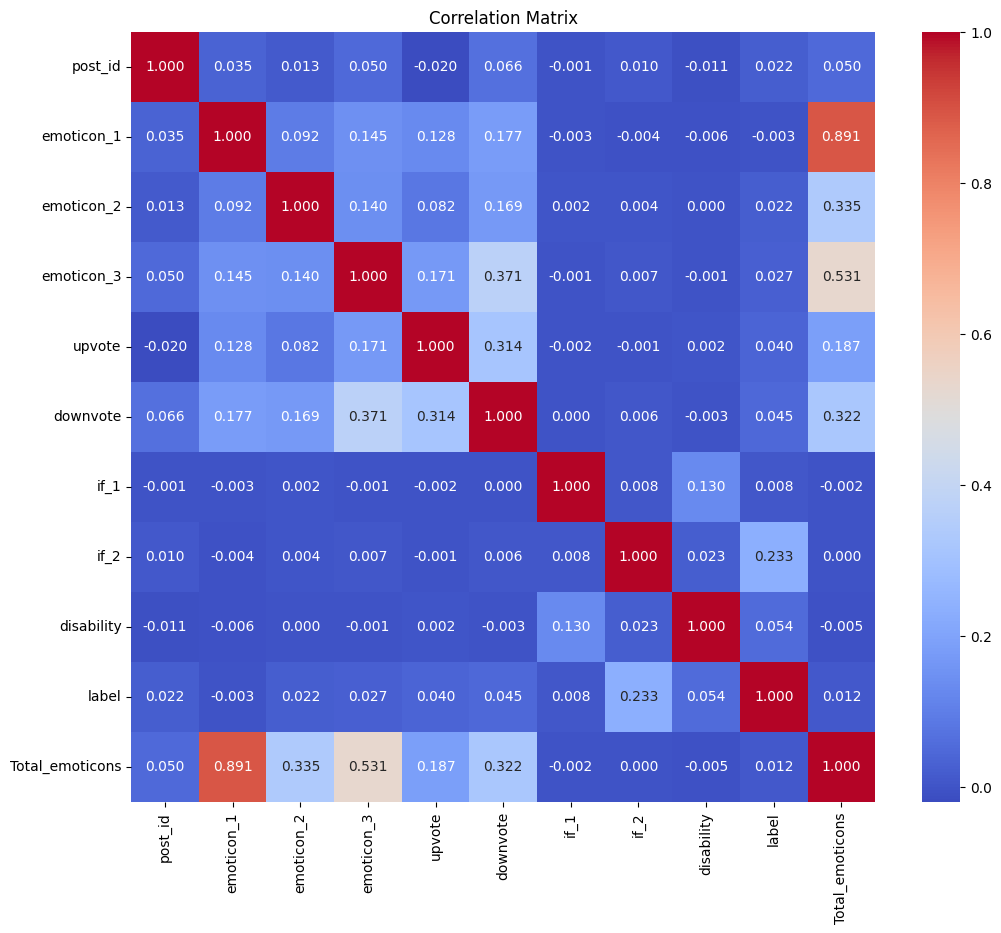

In [23]:
# for numeric columns only doing correlation
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = Train.drop(columns=['comment','race','gender','religion'], errors='ignore')
corr_df = corr_df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
plt.figure(figsize=(12,10))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Correlation Matrix")
plt.show()

In [24]:
Train = Train.drop(['emoticon_1'],axis=1)
Test = Test.drop(['emoticon_1'],axis=1)

## Summary of EDA:
- Very small comment has been filtered out , as they are considered as **noise** to the dataset.
- Des.statitics has done on datset and found that Mean , min-max and quartiles of the datset.
- Outliers has been detected on **comment** feature , because that feature contain more signal than other features.
- Missing values have been detected and further filled out using "" (empty string).
- Corr plot has been plotted to indentify which features are more related to the **label**, helped to remove useless feature.

## PREPROCESSING:

## SPLITTING

* Spliiting the dataset as Train and Validation set for training and validating the model. usually 80:20 train test ratio is used.

In [25]:
x_train, x_val, y_train, y_val = train_test_split(Train.drop('label',axis=1), Train['label'], test_size=0.2,stratify = Train['label'] , random_state = 8)

# MUTUAL INFO

In [26]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X_mi = x_train.copy()
y_mi = y_train.copy()

le_mi = LabelEncoder()

for col in X_mi.columns:
    X_mi[col] = le_mi.fit_transform(X_mi[col].astype(str))

mi = mutual_info_classif(X_mi, y_mi)

import pandas as pd

mi_df = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)
print(mi_df)

if_2               0.501506
if_1               0.064799
race               0.059675
comment            0.046735
religion           0.045562
gender             0.018989
post_id            0.013375
disability         0.002817
downvote           0.002278
emoticon_2         0.001181
upvote             0.001172
emoticon_3         0.001015
Total_emoticons    0.000229
dtype: float64


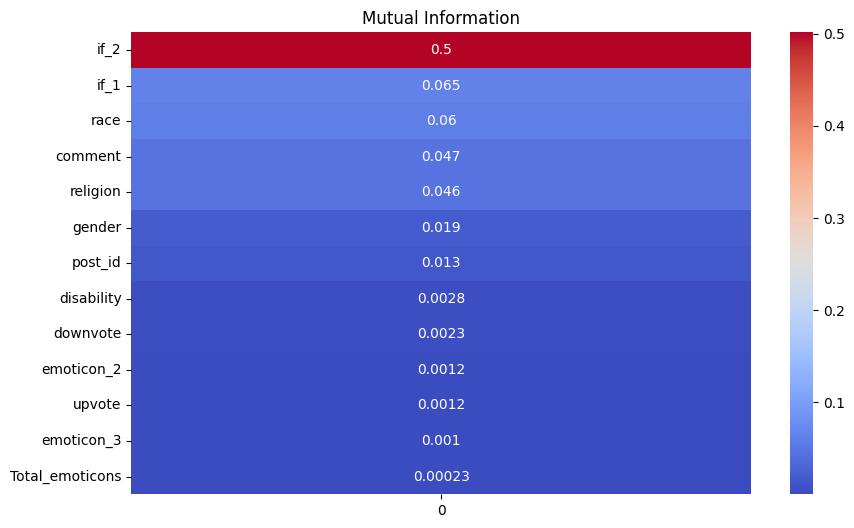

In [27]:
# PLOT FOR MI
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(mi_df.to_frame(), annot=True, cmap="coolwarm")
plt.title("Mutual Information")
plt.show()

In [28]:
x_train.drop(['emoticon_2','post_id'],axis=1,inplace=True)
x_val.drop(['emoticon_2','post_id'],axis=1,inplace=True)
Test.drop(['emoticon_2','post_id'],axis=1,inplace = True)

In [29]:
print(x_train.columns)
print('-'*50)
print(x_val.columns)
print('-'*50)
print(Test.columns)

Index(['emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion',
       'gender', 'disability', 'comment', 'Total_emoticons'],
      dtype='object')
--------------------------------------------------
Index(['emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion',
       'gender', 'disability', 'comment', 'Total_emoticons'],
      dtype='object')
--------------------------------------------------
Index(['emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion',
       'gender', 'disability', 'comment', 'Total_emoticons'],
      dtype='object')


## MULTIVARIATE FEATURE IMPORTANCE

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd


X_mv = x_train.copy()
y_mv = y_train.copy()


for col in X_mv.columns:
    if X_mv[col].dtype == 'object':
        X_mv[col] = X_mv[col].astype('category').cat.codes


model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_mv, y_mv)

imp1 = pd.Series(model.feature_importances_, index=X_mv.columns)


perm = permutation_importance(model, X_mv, y_mv, n_repeats=3, random_state=42)
imp2 = pd.Series(perm.importances_mean, index=X_mv.columns)


final_imp = pd.DataFrame({
    'Model_Importance': imp1,
    'Permutation_Importance': imp2
}).sort_values(by='Permutation_Importance', ascending=False)

print(final_imp)

                 Model_Importance  Permutation_Importance
if_2                     0.559540                0.463618
comment                  0.281797                0.167103
upvote                   0.027262                0.126818
if_1                     0.025676                0.095974
downvote                 0.014403                0.066299
Total_emoticons          0.012162                0.055007
race                     0.036059                0.042440
religion                 0.026976                0.036685
gender                   0.008968                0.030136
emoticon_3               0.004993                0.018745
disability               0.002162                0.005517


In [31]:
x_train.drop(['emoticon_3','disability'],axis=1,inplace=True)
x_val.drop(['emoticon_3','disability'],axis=1,inplace=True)
Test.drop(['emoticon_3','disability'],axis=1,inplace = True)

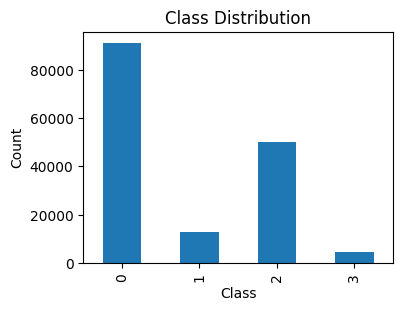

Since the class weights are imbalanced in the provided dataset, it is hence needed to make class weights balanced. Even though for balanced class weight the model prediction was around 0.76 and also the precision for Class 3 is just 48 - 50 % which affects the f1_score, so the class weights are manually assigned for each class. 


In [32]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(4,3))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()
print("Since the class weights are imbalanced in the provided dataset, it is hence needed to make class weights balanced. Even though for balanced class weight the model prediction was around 0.76 and also the precision for Class 3 is just 48 - 50 % which affects the f1_score, so the class weights are manually assigned for each class. ")

In [33]:
# # replacing bool type with int type
# print("Before converting:", x_train['disability'].dtype)

# x_train['disability'] = x_train['disability'].astype(int)
# x_val['disability'] = x_val['disability'].astype(int)
# Test['disability'] = Test['disability'].astype(int)

# print("After converting:", x_train['disability'].dtype)

In [34]:
print(f"x_train shape:",x_train.shape)
print(f"y_train shape:",y_train.shape)
print("")
print(f"x_val shape  :",x_val.shape)
print(f"y_val shape  :",y_val.shape)

x_train shape: (158192, 9)
y_train shape: (158192,)

x_val shape  : (39548, 9)
y_val shape  : (39548,)


## ENCODING

* Machine learning models cannot directly process categorical variables such as **race**, **religion**, **gender**. Therefore, these categorical features are converted into numerical representations using **One-Hot Encoding**.

* One-Hot Encoding creates a separate binary column for each category, where a value of 1 indicates the presence of that category and 0 indicates its absence. This approach allows categorical information to be effectively used during training by model

In [35]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158192 entries, 87170 to 65963
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   upvote           158192 non-null  int64 
 1   downvote         158192 non-null  int64 
 2   if_1             158192 non-null  int64 
 3   if_2             158192 non-null  int64 
 4   race             158192 non-null  object
 5   religion         158192 non-null  object
 6   gender           158192 non-null  object
 7   comment          158192 non-null  object
 8   Total_emoticons  158192 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 12.1+ MB


In [36]:
print("Train")
print(f"Train[race]    :",Train['race'].unique())
print(f"Train[religion]:",Train['religion'].unique())
print(f"Train[gender]  :",Train['gender'].unique())

print("Test")
print(f"Test[race]    :",Test['race'].unique())
print(f"Test[religion]:",Test['religion'].unique())
print(f"Test[gender]  :",Test['gender'].unique())

Train
Train[race]    : ['' 'white' 'other' 'asian' 'black' 'latino']
Train[religion]: ['' 'christian' 'muslim' 'jewish' 'atheist' 'other' 'hindu' 'buddhist']
Train[gender]  : ['' 'male' 'female' 'transgender' 'other']
Test
Test[race]    : ['' 'black' 'other' 'asian' 'white' 'latino']
Test[religion]: ['' 'buddhist' 'atheist' 'muslim' 'christian' 'other' 'jewish' 'hindu']
Test[gender]  : ['' 'male' 'female' 'transgender' 'other']


In [37]:
encoder = OneHotEncoder()
enc_cols = (x_train.select_dtypes(include='object').drop('comment',axis=1)).columns
encoder.fit(x_train[enc_cols])
print(enc_cols) # cols to be encoded

Index(['race', 'religion', 'gender'], dtype='object')


In [38]:
encoded_features = encoder.get_feature_names_out(enc_cols)
encoded_features # cols after encoding

array(['race_', 'race_asian', 'race_black', 'race_latino', 'race_other',
       'race_white', 'religion_', 'religion_atheist', 'religion_buddhist',
       'religion_christian', 'religion_hindu', 'religion_jewish',
       'religion_muslim', 'religion_other', 'gender_', 'gender_female',
       'gender_male', 'gender_other', 'gender_transgender'], dtype=object)

In [39]:
tr = encoder.transform(x_train[enc_cols])
va = encoder.transform(x_val[enc_cols])
te = encoder.transform(Test[enc_cols])
print(va[:6])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (6, 19)>
  Coords	Values
  (0, 0)	1.0
  (0, 6)	1.0
  (0, 14)	1.0
  (1, 0)	1.0
  (1, 6)	1.0
  (1, 14)	1.0
  (2, 3)	1.0
  (2, 12)	1.0
  (2, 14)	1.0
  (3, 0)	1.0
  (3, 6)	1.0
  (3, 16)	1.0
  (4, 0)	1.0
  (4, 6)	1.0
  (4, 14)	1.0
  (5, 0)	1.0
  (5, 6)	1.0
  (5, 14)	1.0


In [40]:
x_train.drop(enc_cols,axis=1,inplace=True)
x_val.drop(enc_cols,axis=1,inplace=True)
Test.drop(enc_cols,axis=1,inplace=True)

In [41]:
x_train[encoded_features] = pd.DataFrame(
    tr.toarray(),
    columns=encoded_features,
    index=x_train.index
)

x_val[encoded_features] = pd.DataFrame(
    va.toarray(),
    columns=encoded_features,
    index=x_val.index
)

Test[encoded_features] = pd.DataFrame(
    te.toarray(),
    columns=encoded_features,
    index=Test.index
) # converting csr to DF

In [42]:
print(f"x_train shape after encoding:",x_train.shape)
print(f"x_val shape after encoding  :",x_val.shape)
print(f"Test shape after encoding   :",Test.shape)

x_train shape after encoding: (158192, 25)
x_val shape after encoding  : (39548, 25)
Test shape after encoding   : (102000, 25)


In [43]:
x_train.head(2)

,upvote,downvote,if_1,if_2,comment,Total_emoticons,race_,race_asian,race_black,race_latino,...,religion_christian,religion_hindu,religion_jewish,religion_muslim,religion_other,gender_,gender_female,gender_male,gender_other,gender_transgender
87170,0,0,0,10,I'm glad you added that last statement I was b...,0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
177982,1,0,4,4,Where are the federal charges??,0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## FEATURE SCALING

* Feature scaling is applied to numerical features to ensure that all variables contribute equally during model training. Many machine learning algorithms, especially gradient based models are sensitive to the scale of input features. If some features have larger scales than others, they can dominate the learning process and negatively affect model performance.

* In this project, **StandardScaler** is used to standardize numerical features by transforming them to have a mean of 0 and a standard deviation of 1. This helps improve model convergence, stabilizes training, and ensures fair weighting of features during optimization.

In [44]:
scaler = StandardScaler(with_mean=False) # just scaling not centering.if scled then sparcity may go. Not good 
columns_to_scale = ['upvote','downvote','if_1','if_2']

x_train[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
x_val[columns_to_scale] = scaler.transform(x_val[columns_to_scale])
Test[columns_to_scale] = scaler.transform(Test[columns_to_scale])

In [45]:
print(f"Scaled x_train shape:",x_train.shape)
print(f"Scaled x_val shape:",x_val.shape)
print(f"Scaled Test shape:",Test.shape)

Scaled x_train shape: (158192, 25)
Scaled x_val shape: (39548, 25)
Scaled Test shape: (102000, 25)


In [46]:
print(x_train.columns)


Index(['upvote', 'downvote', 'if_1', 'if_2', 'comment', 'Total_emoticons',
       'race_', 'race_asian', 'race_black', 'race_latino', 'race_other',
       'race_white', 'religion_', 'religion_atheist', 'religion_buddhist',
       'religion_christian', 'religion_hindu', 'religion_jewish',
       'religion_muslim', 'religion_other', 'gender_', 'gender_female',
       'gender_male', 'gender_other', 'gender_transgender'],
      dtype='object')


In [47]:
x_train.head(2)

,upvote,downvote,if_1,if_2,comment,Total_emoticons,race_,race_asian,race_black,race_latino,...,religion_christian,religion_hindu,religion_jewish,religion_muslim,religion_other,gender_,gender_female,gender_male,gender_other,gender_transgender
87170,0.000000,0.0,0.000000,0.655231,I'm glad you added that last statement I was b...,0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
177982,0.199089,0.0,0.155669,0.262092,Where are the federal charges??,0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [48]:
y_train.head()

87170     2
177982    0
38602     0
49724     2
55037     0
Name: label, dtype: int64

## TF-IDF

* TF-IDF converts text data into numerical features by measuring how important a word is in a document relative to the entire dataset. It helps highlight meaningful words while reducing the influence of very common words.

* **TF (Term Frequency):** Measures how often a word appears in a document.

* **IDF (Inverse Document Frequency):** Reduces the weight of words that appear very frequently across many documents.

Together, TF-IDF highlights important words while giving less weights for  common ones.

In [49]:
traincom = x_train['comment']
valcom = x_val['comment']
testcom = Test['comment']
print(traincom)

87170     I'm glad you added that last statement I was b...
177982                      Where are the federal charges??
38602     Does anyone in the city watch "Dirty Jobs". Mi...
49724     Pls put this show out of its misery. I think D...
55037                                           Amogn who??
                                ...                        
32968     No, it is the discrimination practiced drc by ...
53981     I'm confused about distracted driving..  Is it...
100164    The II was place on there because just "George...
23533     Its not the "issue" epr se.  It is that the Wh...
65963     Over the last 1200 years,  million sand millio...
Name: comment, Length: 158192, dtype: object


In [50]:
char_tfidf = TfidfVectorizer(
    analyzer='char_wb', # groups of letters taken from inside a word
    ngram_range=(3,5), # takes groups of (3 to 5 letters)
    min_df=5,
    max_features=15000,
    sublinear_tf=True
) 

word_tfidf = TfidfVectorizer(
    analyzer = "word",# uses whole words as features
    ngram_range = (1,2),# bigram (combines 2 words )
    min_df=2,
    max_features=20000,
    stop_words='english',
    sublinear_tf=True
)

In [51]:
word_tfidf.fit(traincom)
char_tfidf.fit(traincom)

TfidfVectorizer(analyzer='char_wb', max_features=15000, min_df=5,
                ngram_range=(3, 5), sublinear_tf=True)

In [52]:
train_word = word_tfidf.transform(traincom)
val_word   = word_tfidf.transform(valcom)
test_word  = word_tfidf.transform(testcom)

train_char = char_tfidf.transform(traincom)
val_char   = char_tfidf.transform(valcom)
test_char  = char_tfidf.transform(testcom)

train_comment_vector = hstack([train_word, train_char]) # column wise concating 
val_comment_vector   = hstack([val_word, val_char])
test_comment_vector  = hstack([test_word, test_char])

In [53]:
x_train.drop('comment',axis=1,inplace=True)
x_val.drop('comment',axis=1,inplace=True)
Test.drop('comment',axis=1,inplace=True)

In [54]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158192 entries, 87170 to 65963
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   upvote              158192 non-null  float64
 1   downvote            158192 non-null  float64
 2   if_1                158192 non-null  float64
 3   if_2                158192 non-null  float64
 4   Total_emoticons     158192 non-null  int64  
 5   race_               158192 non-null  float64
 6   race_asian          158192 non-null  float64
 7   race_black          158192 non-null  float64
 8   race_latino         158192 non-null  float64
 9   race_other          158192 non-null  float64
 10  race_white          158192 non-null  float64
 11  religion_           158192 non-null  float64
 12  religion_atheist    158192 non-null  float64
 13  religion_buddhist   158192 non-null  float64
 14  religion_christian  158192 non-null  float64
 15  religion_hindu      158192 non-null 

In [55]:
print(Test.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   upvote              102000 non-null  float64
 1   downvote            102000 non-null  float64
 2   if_1                102000 non-null  float64
 3   if_2                102000 non-null  float64
 4   Total_emoticons     102000 non-null  int64  
 5   race_               102000 non-null  float64
 6   race_asian          102000 non-null  float64
 7   race_black          102000 non-null  float64
 8   race_latino         102000 non-null  float64
 9   race_other          102000 non-null  float64
 10  race_white          102000 non-null  float64
 11  religion_           102000 non-null  float64
 12  religion_atheist    102000 non-null  float64
 13  religion_buddhist   102000 non-null  float64
 14  religion_christian  102000 non-null  float64
 15  religion_hindu      102000 non-nul

In [56]:
# Converting dataframe to csr matrix
X_train_num = csr_matrix(x_train.values)
X_val_num = csr_matrix(x_val.values)
X_test_num = csr_matrix(Test.values)

# combining numeric and tfidf columns
X_train_final = hstack([X_train_num, train_comment_vector])
X_val_final = hstack([X_val_num, val_comment_vector])
X_test_final = hstack([X_test_num, test_comment_vector])

In [57]:
print(f"Train shape after tf-idf:",X_train_final.shape)
print(f"Val shape after tf-idf:",X_val_final.shape)
print(f"Test shape after tf-idf:",X_test_final.shape)

Train shape after tf-idf: (158192, 35024)
Val shape after tf-idf: (39548, 35024)
Test shape after tf-idf: (102000, 35024)


## FEATURE SELECTION

- The Feature Selector used here is the SelectPercentile which is a Filter based feature seelctor

- Based on chi2 score , the top 18 percentile features are selected to feed into the model for prediction , so that we can prevent noises in datas,reduce computation cost and hence we can prevent model from overfitting.

In [58]:
training = X_train_final
validating = X_val_final
testing = X_test_final
y_training = y_train
y_validating = y_val

print(f"training shape   :",training.shape)
print(f"validating shape :",validating.shape)
print(f"testing shape    :",testing.shape)

training shape   : (158192, 35024)
validating shape : (39548, 35024)
testing shape    : (102000, 35024)


In [59]:
selector = SelectPercentile(chi2,percentile=18)

selector.fit(training,y_training)
selected_train = selector.transform(training)
selected_val = selector.transform(validating)
selected_test = selector.transform(testing)

In [60]:
print(f"selected_train shape:",selected_train.shape)
print(f"selected_val shape  :",selected_val.shape)
print(f"selected_test shape :",selected_test.shape) 
print(f"y_training shape    :",y_training.shape)
print(f"y_validating shape  :",y_validating.shape)

selected_train shape: (158192, 6305)
selected_val shape  : (39548, 6305)
selected_test shape : (102000, 6305)
y_training shape    : (158192,)
y_validating shape  : (39548,)


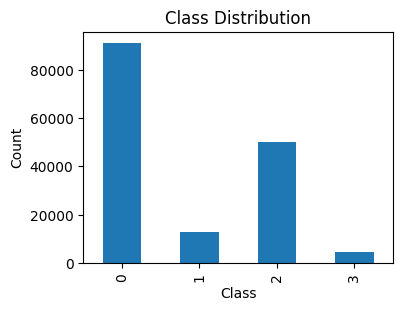

Since the class weights are imbalanced in the provided dataset, it is hence needed to make class weights balanced. Even though for balanced class weight the model prediction was around 0.76 and also the precision for Class 3 is just 48 - 50 % which affects the f1_score, so the class weights are manually assigned for each class. 


In [61]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(4,3))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()
print("Since the class weights are imbalanced in the provided dataset, it is hence needed to make class weights balanced. Even though for balanced class weight the model prediction was around 0.76 and also the precision for Class 3 is just 48 - 50 % which affects the f1_score, so the class weights are manually assigned for each class. ")

In [62]:
class_weights = {
    0: 0.8,
    1: 1.3, 
    2: 1.0,
    3: 2.6    
} # Manual weights assigned for models using weights

class_weights_gbm ={
    0: 0.8,
    1: 1.3,
    2: 0.8,#1.0
    3: 3.7
} # Manual weights exclusively assigned for Light-GBM model

## MODELS

- **Logistic Regression**  
  A linear classification algorithm that predicts the probability of a data point belonging to a class.

- **Stochastic Gradient Descent (SGD)**  
  A linear model trained using Stochastic Gradient Descent, efficient for large datasets.

- **Multi Layer Perceptron (MLP)**  
  A neural network model with multiple layers that can learn complex patterns in data.

- **LightGBM**  
  A gradient boosting model that builds trees sequentially to correct previous errors and improve performance.

- **Naive Bayes**
 
  A probabilistic classification algorithm based on Bayes’ theorem that assumes features are independent of each other.
  - **Multinomial Naive Bayes**  
  Works well for text data by using word frequency counts to estimate class probabilities.

  - **Complement Naive Bayes**  
  A variation of Multinomial Naive Bayes designed to handle imbalanced datasets more effectively.

In [63]:
# LOG 
Model_log = LogisticRegression(
    penalty='l2', # because features are only slightly correlated
    solver='sag', # fast optimizer for logistic regression on large datasets (Stochastic Average Gradient (SAG))
    random_state=8,
    C=1.0, 
    class_weight=class_weights,
    max_iter=8000
) 
#--------------------------------------------------------------------------------------------------------------------------------------------------------
# SGD
Model_sgd = SGDClassifier(
    loss="hinge",  # used for classification by maximizing the margin between classes (kinda SVM)
    alpha=5e-5,  # weak regularizing only                
    penalty="l2",
    max_iter=7000,
    tol=1e-4,
    class_weight=class_weights,
    learning_rate="optimal",
    random_state=8
)
#--------------------------------------------------------------------------------------------------------------------------------------------------------
# MLP
Model_mlp =  MLPClassifier(
    hidden_layer_sizes=(100,), # (100,) Best
    activation='logistic',
    solver='adam', # adaptive optimizer that adjusts learning rate automatically
    max_iter=8000,
    learning_rate = 'adaptive',
    random_state=8,
    validation_fraction=0.2, # given this for the early stopping
    early_stopping=True
)
#--------------------------------------------------------------------------------------------------------------------------------------------------------
# LightGBM
from lightgbm import LGBMClassifier
Model_gbm = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=700,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=20,
    min_child_samples=180,#180 (best)
    subsample=0.7,
    colsample_bytree=0.6,#0.6 (best)
    feature_fraction_bynode=0.6,#0.6 (best)
    reg_alpha=2.5,
    reg_lambda=2.5,
    class_weight=class_weights_gbm,
    random_state=8,
    n_jobs=-1,
    verbosity=-1 # To prevent seeing the Logs of the model while running
)


## MODEL TRAINING & PREDICTION

In [64]:
Model_log.fit(selected_train,y_training) # log reg

LogisticRegression(class_weight={0: 0.8, 1: 1.3, 2: 1.0, 3: 2.6}, max_iter=8000,
                   random_state=8, solver='sag')

In [65]:
Model_sgd.fit(selected_train,y_training) # SGD-C

SGDClassifier(alpha=5e-05, class_weight={0: 0.8, 1: 1.3, 2: 1.0, 3: 2.6},
              max_iter=7000, random_state=8, tol=0.0001)

In [66]:
Model_mlp.fit(selected_train,y_training) # MLP classsifier

MLPClassifier(activation='logistic', early_stopping=True,
              learning_rate='adaptive', max_iter=8000, random_state=8,
              validation_fraction=0.2)

In [67]:
Model_gbm.fit(selected_train,y_training) # GBM

LGBMClassifier(class_weight={0: 0.8, 1: 1.3, 2: 0.8, 3: 3.7},
               colsample_bytree=0.6, feature_fraction_bynode=0.6,
               learning_rate=0.03, max_depth=6, min_child_samples=180,
               n_estimators=700, n_jobs=-1, num_class=4, num_leaves=20,
               objective='multiclass', random_state=8, reg_alpha=2.5,
               reg_lambda=2.5, subsample=0.7, verbosity=-1)

## HYPERPARAMETER TUNING & CV

Hyperparameter tunining is done for finding the Optimal setting for the given model , so that it converges better.
CV is done with K-fold for just finding how my model performs on each folds

- Logistic regression
- Naive Bayes
- MLP


In [68]:
# # Multinomial Naive Bayes CV
# from sklearn.naive_bayes import MultinomialNB

# for a in [1.0, 0.5, 0.1, 0.05]: # smoothening parameter
#     nb = MultinomialNB(alpha=a)
#     nb.fit(selected_train, y_training)
#     y_pred_nb = nb.predict(selected_val)
#     score = f1_score(y_validating, y_pred_nb, average="macro")
#     print(f"Multinomial alpha - {a} : f1_macro = {score}")

- Multinomial alpha - 1.0 : f1_macro = 0.6471122365156654
- Multinomial alpha - 0.5 : f1_macro = 0.6512149648835204
- Multinomial alpha - 0.1 : f1_macro = 0.653950251737295
- Multinomial alpha - 0.05 : f1_macro = 0.6548585580072707

In [69]:
# # Complement Naive Bayes CV
# from sklearn.naive_bayes import ComplementNB

# for a in [1.0, 0.5, 0.1, 0.05]:
#     com_nb = ComplementNB(alpha=a , class_prior = [0.4, 0.2, 0.3, 0.1] )
#     com_nb.fit(selected_train, y_training)
#     y_pred_com = com_nb.predict(selected_val)
#     score = f1_score(y_validating, y_pred_com, average="macro")
#     print(f"Complement alpha = {a} : f1_macro = {score}")

- Complement alpha = 1.0 : f1_macro = 0.6451875663997952
- Complement alpha = 0.5 : f1_macro = 0.6463576899892729
- Complement alpha = 0.1 : f1_macro = 0.6476319798185954
- Complement alpha = 0.05 : f1_macro = 0.6476867664143396

- Since even for multiple alphas and dedicated class_prior also for 'fit_prior = True' the MultinomialNB and ComplimemtNB just gives f1_macro score around ~ 0.64, considering Naive bayes as our final model isn't a good option. 

In [70]:
# from sklearn.model_selection import RandomizedSearchCV
# macro_f1 = make_scorer(f1_score,average='macro')
# param_dist = {
#     "C": [0.001, 0.01, 0.1, 1, 10, 100]
# }

# random_search = RandomizedSearchCV(
#     Model_log,              
#     param_distributions=param_dist,
#     n_iter=6, # use all 6 'C'             
#     cv=5,
#     scoring=macro_f1,
#     n_jobs=-1,
#     random_state=8
# )
# random_search.fit(selected_train, y_train)

# print("Best C:", random_search.best_params_)
# print("Best Score:", random_search.best_score_)

Taking more than 6 hours

In [71]:
# # k folds Log reg
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.metrics import make_scorer, f1_score
# skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=8)
# macro_f1 = make_scorer(f1_score,average='macro')
# scores = cross_val_score(
#     Model_log,
#     selected_train,
#     y_training,
#     cv=skf,
#     scoring=macro_f1,
#     n_jobs=-1
# )
# print("Fold scores:", scores)
# print("Mean macro F1:", scores.mean())

- Fold scores: [0.82081374 , 0.8179807 , 0.8182188 , 0.81470023 , 0.82136834]
- Mean macro F1:  0.8186163610422245

In [72]:
# cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 8 )
# macro_f1 = make_scorer(f1_score,average='macro')
# scores = cross_val_score(Model_mlp, selected_train, y_training, cv=cv, scoring=macro_f1)
# print("CV scores:", scores)
# print("Mean macro f1:", np.mean(scores)) # av f1 score of mlp n_splits

- CV scores: [0.82503572 , 0.81814539 , 0.8146822 ]
- Mean macro f1: 0.8192877726477729

### Confusion matrix & prediction

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0    0.97672   0.93686   0.95637     22790
           1    0.77278   0.77764   0.77520      3184
           2    0.85785   0.91058   0.88343     12480
           3    0.62571   0.70750   0.66409      1094

    accuracy                        0.90940     39548
   macro avg    0.80827   0.83314   0.81977     39548
weighted avg    0.91308   0.90940   0.91068     39548



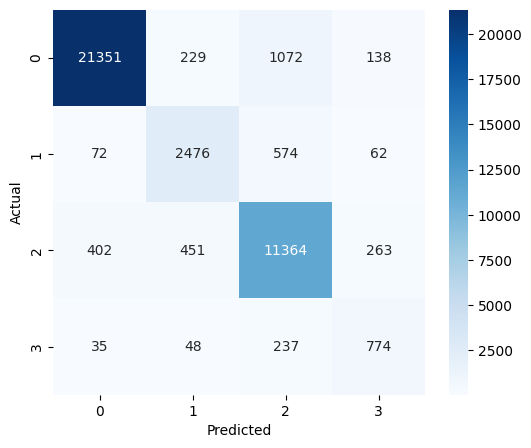

SGD
              precision    recall  f1-score   support

           0    0.97508   0.93932   0.95687     22790
           1    0.76220   0.70666   0.73338      3184
           2    0.82457   0.91819   0.86886     12480
           3    0.72215   0.49177   0.58510      1094

    accuracy                        0.90154     39548
   macro avg    0.82100   0.76398   0.78605     39548
weighted avg    0.90345   0.90154   0.90082     39548



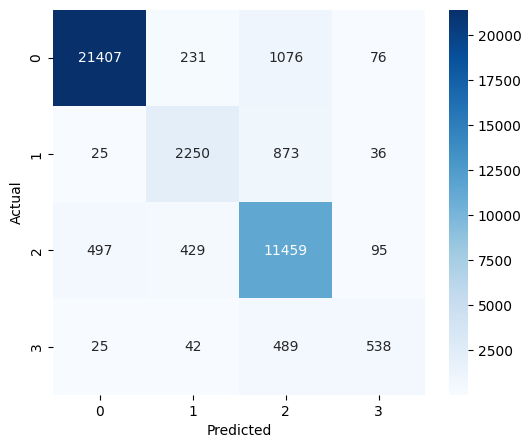

MLP
              precision    recall  f1-score   support

           0    0.97951   0.93967   0.95917     22790
           1    0.80631   0.77010   0.78779      3184
           2    0.84885   0.92788   0.88661     12480
           3    0.69162   0.63346   0.66126      1094

    accuracy                        0.91383     39548
   macro avg    0.83157   0.81778   0.82371     39548
weighted avg    0.91637   0.91383   0.91424     39548



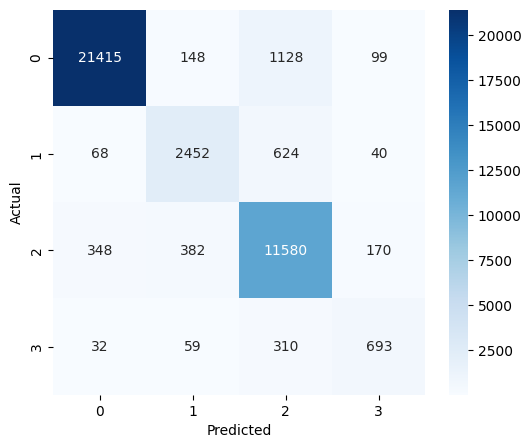

L-GBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0    0.97669   0.94695   0.96159     22790
           1    0.76109   0.80842   0.78404      3184
           2    0.86863   0.88694   0.87769     12480
           3    0.58553   0.71024   0.64188      1094

    accuracy                        0.91031     39548
   macro avg    0.79799   0.83814   0.81630     39548
weighted avg    0.91441   0.91031   0.91198     39548



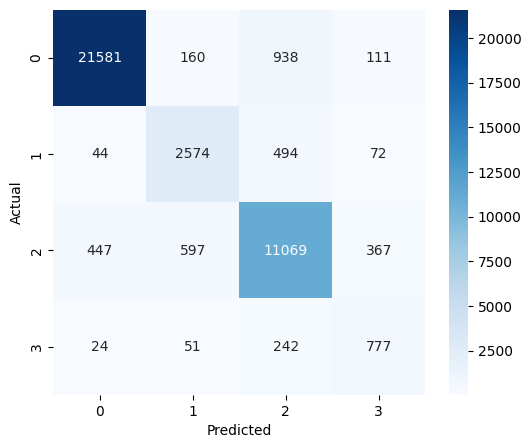

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [73]:
# CONFUSION MATRIX
from sklearn.metrics import classification_report , confusion_matrix

# LOGISTIC
print('LOGISTIC REGRESSION')

y_Pred_log = Model_log.predict(selected_val) # Log.reg
y_Pred_log_train = Model_log.predict(selected_train) # Log.reg

print(classification_report(y_validating,y_Pred_log,digits=5))
cm = confusion_matrix(y_validating,y_Pred_log)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print('='*50)

# SGD
print("SGD")

y_Pred_sgd = Model_sgd.predict(selected_val) # Log.reg
y_Pred_sgd_train = Model_sgd.predict(selected_train) # Log.reg

print(classification_report(y_validating,y_Pred_sgd,digits=5))
cm = confusion_matrix(y_validating,y_Pred_sgd)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print('='*50)

# MLP
print("MLP")

y_Pred_mlp = Model_mlp.predict(selected_val) # MLP Classifer
y_Pred_mlp_train = Model_mlp.predict(selected_train) # MLP Classifier

print(classification_report(y_validating,y_Pred_mlp,digits=5))
cm = confusion_matrix(y_validating,y_Pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print('='*50)

# GBM
print("L-GBM")

y_Pred_gbm = Model_gbm.predict(selected_val) # MLP Classifer
y_Pred_gbm_train = Model_gbm.predict(selected_train) # MLP Classifier

print(classification_report(y_validating,y_Pred_gbm,digits=5))
cm = confusion_matrix(y_validating,y_Pred_gbm)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print('='*50)

# test predictions
y_Pred_log_test = Model_log.predict(selected_test) # Log.reg
y_Pred_sgd_test = Model_sgd.predict(selected_test) # SGD
y_Pred_mlp_test = Model_mlp.predict(selected_test) # MLP Classifier
y_Pred_gbm_test = Model_gbm.predict(selected_test) # gbm Classifier 

In [74]:
#  f1 score
f1_macro_log_train = f1_score(y_training, y_Pred_log_train , average = 'macro')
f1_macro_log = f1_score(y_validating, y_Pred_log , average = 'macro')

f1_macro_sgd_train = f1_score(y_training , y_Pred_sgd_train, average = "macro")
f1_macro_sgd = f1_score(y_validating , y_Pred_sgd, average = "macro")

f1_macro_mlp_train = f1_score(y_training , y_Pred_mlp_train, average = "macro")
f1_macro_mlp = f1_score(y_validating , y_Pred_mlp, average = "macro")

f1_macro_gbm_train = f1_score(y_training, y_Pred_gbm_train , average='macro') 
f1_macro_gbm = f1_score(y_validating, y_Pred_gbm , average="macro")

print(f"logistic val            :",f1_macro_log)
print(f"logistic train          :",f1_macro_log_train)

print("")

print(f"SGD val                 :",f1_macro_sgd)
print(f"SGD train               :",f1_macro_sgd_train)

print("")

print(f"MLP val                 :",f1_macro_mlp)
print(f"MLP train               :",f1_macro_mlp_train)

print("")

print(f"gbm val                  :",f1_macro_gbm)
print(f"gbm train                :",f1_macro_gbm_train)

logistic val            : 0.8197744527157752
logistic train          : 0.8408718048845238

SGD val                 : 0.7860515351170436
SGD train               : 0.7980528580094022

MLP val                 : 0.8237084427213428
MLP train               : 0.8570821738863839

gbm val                  : 0.8163012729567667
gbm train                : 0.8475130674635216


## COMPARISION

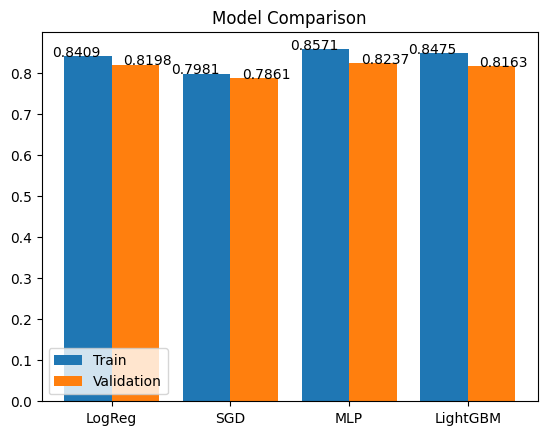

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, accuracy_score

models = ["LogReg", "SGD", "MLP", "LightGBM"]

# Validation metrics
precision_log = precision_score(y_validating, y_Pred_log, average="macro")
recall_log = recall_score(y_validating, y_Pred_log, average="macro")
accuracy_log = accuracy_score(y_validating, y_Pred_log)

precision_sgd = precision_score(y_validating, y_Pred_sgd, average="macro")
recall_sgd = recall_score(y_validating, y_Pred_sgd, average="macro")
accuracy_sgd = accuracy_score(y_validating, y_Pred_sgd)

precision_mlp = precision_score(y_validating, y_Pred_mlp, average="macro")
recall_mlp = recall_score(y_validating, y_Pred_mlp, average="macro")
accuracy_mlp = accuracy_score(y_validating, y_Pred_mlp)

precision_gbm = precision_score(y_validating, y_Pred_gbm, average="macro")
recall_gbm = recall_score(y_validating, y_Pred_gbm, average="macro")
accuracy_gbm = accuracy_score(y_validating, y_Pred_gbm)

train_scores = [
    f1_macro_log_train,
    f1_macro_sgd_train,
    f1_macro_mlp_train,
    f1_macro_gbm_train
]

val_scores = [
    f1_macro_log,
    f1_macro_sgd,
    f1_macro_mlp,
    f1_macro_gbm
]

# PLOTTING 
x = np.arange(len(models)) # [0,1,2,3]

plt.bar(x - 0.2, train_scores, width=0.4)
plt.bar(x + 0.2, val_scores, width=0.4)
# training data
plt.text(x[0] - 0.5, train_scores[0], round(train_scores[0],4)) # for value placement
plt.text(x[1] - 0.5, train_scores[1], round(train_scores[1],4))
plt.text(x[2] - 0.5, train_scores[2], round(train_scores[2],4))
plt.text(x[3] - 0.5, train_scores[3], round(train_scores[3],4))
# testing data
plt.text(x[0] + 0.1, val_scores[0], round(val_scores[0],4))
plt.text(x[1] + 0.1, val_scores[1], round(val_scores[1],4))
plt.text(x[2] + 0.1, val_scores[2], round(val_scores[2],4))
plt.text(x[3] + 0.1, val_scores[3], round(val_scores[3],4))

plt.xticks(x, models) # kind of indexing the models positoin to be in plot
plt.legend(["Train", "Validation"])
plt.title("Model Comparison")

plt.show()

### VOTING CLASSIFER
- An ensemble method that combines predictions from multiple models and selects the final output based on majority voting.

In [76]:
from sklearn.ensemble import VotingClassifier 
ensemble = VotingClassifier(
    estimators=[
        ('log', Model_log),
        ('mlp', Model_mlp),
        ('gbm', Model_gbm)
    ],
    voting='soft',
    weights=(1,2,1)
)
ensemble.fit(selected_train,y_training)

VotingClassifier(estimators=[('log',
                              LogisticRegression(class_weight={0: 0.8, 1: 1.3,
                                                               2: 1.0, 3: 2.6},
                                                 max_iter=8000, random_state=8,
                                                 solver='sag')),
                             ('mlp',
                              MLPClassifier(activation='logistic',
                                            early_stopping=True,
                                            learning_rate='adaptive',
                                            max_iter=8000, random_state=8,
                                            validation_fraction=0.2)),
                             ('gbm',
                              LGBMClassifier(class_weight={0: 0.8, 1: 1.3,
                                                           2: 0.8, 3: 3.7},
                                             colsample_bytree=0.6,
                                             feature_fraction_bynode=0.6,
                                             learning_rate=0.03, max_depth=6,
                                             min_child_samples=180,
                                             n_estimators=700, n_jobs=-1,
                                             num_class=4, num_leaves=20,
                                             objective='multiclass',
                                             random_state=8, reg_alpha=2.5,
                                             reg_lambda=2.5, subsample=0.7,
                                             verbosity=-1))],
                 voting='soft', weights=(1, 2, 1))

In [77]:
y_vot_pred = ensemble.predict(selected_val)
y_vot_pred_train = ensemble.predict(selected_train)
print('Training score:',f1_score(y_training,y_vot_pred_train,average='macro'))
print('Testing score :',f1_score(y_validating,y_vot_pred,average='macro'))
y_pred_vot_test = ensemble.predict(selected_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training score: 0.8593386770308645
Testing score : 0.8297705328629552


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


VOTING CLASSIFIER
              precision    recall  f1-score   support

           0    0.98069   0.94247   0.96120     22790
           1    0.79377   0.78455   0.78913      3184
           2    0.85691   0.92083   0.88772     12480
           3    0.68290   0.67916   0.68103      1094

    accuracy                        0.91565     39548
   macro avg    0.82857   0.83175   0.82977     39548
weighted avg    0.91834   0.91565   0.91641     39548



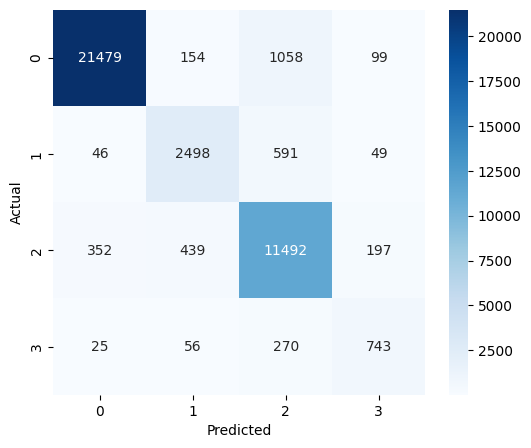

In [78]:
print("VOTING CLASSIFIER")

print(classification_report(y_validating,y_vot_pred,digits=5))
cm = confusion_matrix(y_validating,y_vot_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Out of all the models that predicted the Dataset labels, well predicted models are:
    - Logistic Regression
    - Light GBM
    - Multi Layer Perceptron (MLP)
With the thought of combining them would provide better performance , the models were combined using Voting classifer and indeed it provided good result.

      
  

## FINAL INFERENCE

After completing model training and evaluation, the final model used for inference was a **soft voting ensemble** combining Logistic Regression, MLP and Light-GBM models. This ensembling helps to improve generalization by combining the performance strengths of both models.

The overall process steps are:

1. Convert the text comments into numerical features using **TF-IDF (character and word level)**.
2. Apply **feature selection (Filter based)** to keep the most informative features.
3. Hyperparameter tuning the models for better genaralization.
4. Giving the good performing models into the **VotingClassifier ensemble**.
5. Generate predictions and metrics for the **test dataset** and  check for **Overfitting**.
6. Save the predicted labels into a **submission file** for Kaggle evaluation.


In [79]:
print(f"Best Performing Model : Voting classifier ensemble ")

Best Performing Model : Voting classifier ensemble 


In [80]:
sample['label'] = y_pred_vot_test

In [81]:
sample['label'].value_counts()

label
0    56519
2    34739
1     8023
3     2719
Name: count, dtype: int64

In [82]:
sample['label'].unique() # all classes are present

array([2, 0, 1, 3])

In [83]:
 sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   ID      102000 non-null  int64
 1   label   102000 non-null  int64
dtypes: int64(2)
memory usage: 1.6 MB


In [84]:
sample.to_csv("submission.csv",index=False)

# APPENDIX

## Milestone-1

In [85]:
# train.shape

In [86]:
# test.shape

In [87]:
# train.info()

In [88]:
# test_cols = test.columns
# test_cols

In [89]:
# object_train_columns = train.select_dtypes(["object"]).columns
# count = 0
# for i in object_train_columns:
#     count+=1
# print(f"Number of columns in training datset with 'object' data type:{count}")

In [90]:
# numerical_train_columns = train.select_dtypes(["int64"]).columns
# count1 = 0
# for i in numerical_train_columns:
#     count1+=1
# print(f"Number of columns in training datset with 'numerical' data type:{count1}")

In [91]:
# bool_column_train = train.select_dtypes(["bool"]).columns
# print(f"Boolean column in train dataset : {bool_column_train}")

In [92]:
# train.isna().sum()

In [93]:
# missing_values = pd.DataFrame(train.isna().sum())
# missing_values[missing_values[0] > 0]

In [94]:
# unique_class = train["label"].unique()
# count2=0
# for i in list(unique_class):
#     count2+=1
# print(f"No of Distinct target classes in dataset : {count2}")


In [95]:
# Total_samples = train.shape[0]
# Total_samples

In [96]:
# dataset_belongs_0 = train[train["label"]==0]
# dataset_belongs_0 = dataset_belongs_0.shape[0]
# dataset_belongs_0

In [97]:
# percentage_of_dataset_to_0 = (dataset_belongs_0 / Total_samples) * 100
# print(f"percentage of the dataset approximately belongs to label 0 : {round(percentage_of_dataset_to_0 , 2)}")

In [98]:
# if_2_unique = train["if_2"].unique()
# np.sort(if_2_unique)

In [99]:
# train["if_2"].min()

In [100]:
# train[numerical_train_columns].max()

In [101]:
# train["upvote"].median()

In [102]:
# train.head()

In [103]:
# test.head()

In [104]:
# train.columns

In [105]:
# X = train.drop("label",axis = 1)
# y = train["label"] 

In [106]:
# X.head()

In [107]:
# y.head()

In [108]:
# y.unique()

## MILESTONE 2

In [109]:
# TRAIN = train.copy()
# TEST = test.copy()

In [110]:
# TRAIN['created_date'] = pd.to_datetime(TRAIN['created_date'])

In [111]:
# TRAIN.describe()

In [112]:
# TRAIN['created_date'].dt.month_name().value_counts().sort_index()

In [113]:
# TRAIN['hour'] = TRAIN['created_date'].dt.hour
# TRAIN['day_of_week'] = TRAIN['created_date'].dt.dayofweek
# TRAIN['is_weekend'] = (TRAIN['created_date'].dt.dayofweek >= 5).astype(int)
# TRAIN['month_name'] = TRAIN['created_date'].dt.month_name()
# TRAIN['comment_length'] = TRAIN['comment'].str.len()
# TRAIN['word_count'] = TRAIN['comment'].str.split().str.len()
# TRAIN['exclamation_count'] = TRAIN['comment'].fillna('').str.count('!')
# TRAIN['question_count']    = TRAIN['comment'].fillna('').str.count(r'\?')
# TRAIN['upper_word_count'] = TRAIN['comment'].fillna('').apply(
#     lambda x: sum(1 for w in x.split() if w.isupper())
# )
# TRAIN['total_emoticons'] = TRAIN['emoticon_1'] + TRAIN['emoticon_2'] + TRAIN['emoticon_3']

In [114]:
# TRAIN['total_emoticons'].max()

In [115]:
# TRAIN['comment'] = TRAIN['comment'].fillna('')
# TRAIN['char_length'] = TRAIN['comment'].str.len()
# median_length = TRAIN[TRAIN['label'] == 3]['char_length'].median()
# print(median_length)

In [116]:
# min_val = TRAIN['upvote'].min()
# max_val = TRAIN['upvote'].max()
# upvotes = 10
# scaled_value = (upvotes - min_val) / (max_val - min_val)
# print(round(scaled_value, 4))

In [117]:
# avg_word_count = TRAIN[TRAIN['label'] == 1]['word_count'].mean()
# print(round(avg_word_count, 2))

In [118]:
# count_trump = TRAIN['comment'].str.contains('trump', case=False).sum()
# print(count_trump)

In [119]:
# zero_index_comment = TRAIN.loc[0, 'comment']
# print(zero_index_comment)
# zero_index_comment = '' if pd.isna(zero_index_comment) else zero_index_comment

# zero_index_comment = pd.Series(zero_index_comment).str.replace(r'[^\w\s]', '', regex=True).iloc[0]
# zero_index_comment = zero_index_comment.lower()

# words = [i for i in zero_index_comment.split() if i not in stop_words]
# print(len(words))

In [120]:
# TRAIN['comment_lower'] = TRAIN['comment'].str.lower()

# tokens = TRAIN['comment_lower'].str.split()
# all_tokens = [word for sublist in tokens for word in sublist]
# unique_token_count = len(set(all_tokens))
# print(unique_token_count)
# print(all_tokens[:20])

In [121]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# TFIDF = TfidfVectorizer(
#     stop_words='english',
#     min_df=5,
#     ngram_range=(1,2)
# )
# X = TFIDF.fit_transform(TRAIN['comment'])
# num_features = len(TFIDF.get_feature_names_out())
# print(num_features)

## MILESTONE 3

In [122]:
# TR = train.copy()
# TE = test.copy()
# X_train , X_val , Y_train , Y_val = train_test_split(TR.drop('label',axis=1),TR['label'],test_size=0.2,random_state=42)
# print(X_train.shape)
# print(X_val.shape)

In [123]:
# print(X_train.shape[0] + X_val.shape[0])

In [124]:
# X_train["created_date"] = pd.to_datetime(X_train['created_date'])
# X_train['day'] = X_train['created_date'].dt.day
# X_train['month'] = X_train['created_date'].dt.month_name()
# X_train['year']  = X_train['created_date'].dt.year

# X_val["created_date"] = pd.to_datetime(X_val['created_date'])
# X_val['day'] = X_val['created_date'].dt.day
# X_val['month'] = X_val['created_date'].dt.month_name()
# X_val['year']  = X_val['created_date'].dt.year
# print(X_train['month'].value_counts())

In [125]:
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# import pandas as pd

# cat_cols = ['religion', 'gender', 'race']

# cat_pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
#     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[('cat', cat_pipeline, cat_cols)],
#     remainder='passthrough'
# )

# X_train = preprocessor.fit_transform(X_train)
# X_val   = preprocessor.transform(X_val)

# cat_transformer = preprocessor.named_transformers_['cat']
# Ohe = cat_transformer.named_steps['ohe']
# ohe_cols=Ohe.get_feature_names_out(cat_cols)

# other_cols = [c for c in preprocessor.feature_names_in_ if c not in cat_cols]
# final_cols = list(ohe_cols) + list(other_cols)

# # convert back to pandas
# X_train = pd.DataFrame(X_train, columns=final_cols)
# X_val   = pd.DataFrame(X_val, columns=final_cols)

# # value of b
# b = X_train.shape[1]
# b

In [126]:
# X_train.info()

In [127]:
# from sklearn.feature_extraction.text import CountVectorizer
# cv = CountVectorizer()
# X_train['comment'] = X_train['comment'].fillna('none')
# X_val['comment']   = X_val['comment'].fillna('none')
# X_train_cv = cv.fit_transform(X_train['comment'])
# X_val_cv   = cv.transform(X_val['comment'])  
# result = X_train_cv[1].sum()
# result

In [128]:
# X_train['disability'] = X_train['disability'].map({True: 1, False: 0}).astype(int)
# X_val['disability']   = X_val['disability'].map({True: 1, False: 0}).astype(int)

# X_train['disability'].sum() + X_val['disability'].sum()

In [129]:
# from sklearn.preprocessing import StandardScaler

# # drop datetime columns
# dt_cols = X_train.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns
# X_train_num = X_train.drop(columns=dt_cols)
# X_val_num   = X_val.drop(columns=dt_cols)

# # keep only numeric features
# X_train_num = X_train_num.select_dtypes(include=['int64', 'float64'])
# X_val_num   = X_val_num.select_dtypes(include=['int64', 'float64'])

# scaler = StandardScaler()

# scaler.fit(X_train_num)
# scaler.n_features_in_

In [130]:
# from sklearn.impute import SimpleImputer
# from sklearn.naive_bayes import MultinomialNB

# # split
# X = TR.drop('label', axis=1)
# y = TR['label']

# X_train, X_val, Y_TRAIN, Y_VAL = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # impute (numeric + non-numeric separately)
# num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
# obj_cols = X_train.select_dtypes(include=['object', 'bool']).columns

# num_imp = SimpleImputer(strategy='median')
# obj_imp = SimpleImputer(strategy='most_frequent')

# X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
# X_val[num_cols]   = num_imp.transform(X_val[num_cols])

# X_train[obj_cols] = obj_imp.fit_transform(X_train[obj_cols])
# X_val[obj_cols]   = obj_imp.transform(X_val[obj_cols])

# # to ensure no negative numeric values
# X_train[num_cols] = X_train[num_cols].abs()
# X_val[num_cols]   = X_val[num_cols].abs()

# # created_date → day, month, year
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date']   = pd.to_datetime(X_val['created_date'])

# for d in [X_train, X_val]: # easier to do than doing singly
#     d['day']   = d['created_date'].dt.day
#     d['month'] = d['created_date'].dt.month
#     d['year']  = d['created_date'].dt.year
#     d.drop(columns=['created_date'], inplace=True)


# # columns
# text_col = 'comment'

# cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
# if text_col in cat_cols:
#     cat_cols.remove(text_col)

# num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # preprocessing + model
# preprocess = ColumnTransformer(
#     transformers=[
#         ('text', TfidfVectorizer(stop_words='english'), text_col),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
#         ('num', 'passthrough', num_cols)
#     ]
# )

# pipe = Pipeline([
#     ('prep', preprocess),
#     ('nb', MultinomialNB(alpha=0.3))
# ])

# # train + macro F1 on TRAIN
# pipe.fit(X_train, Y_TRAIN)

# train_preds = pipe.predict(X_train)
# val_preds = pipe.predict(X_val)
# print(f1_score(Y_TRAIN, train_preds, average='macro'))
# print(f1_score(Y_VAL,val_preds,average='macro'))

In [131]:
# from sklearn.impute import SimpleImputer
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import f1_score

# # split raw data
# X = TR.drop('label', axis=1)
# y = TR['label']

# X_train, X_val, Y_TRAIN, Y_VAL = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # imputation
# num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
# obj_cols = X_train.select_dtypes(include=['object', 'bool']).columns

# num_imp = SimpleImputer(strategy='median')
# obj_imp = SimpleImputer(strategy='most_frequent')

# X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
# X_val[num_cols]   = num_imp.transform(X_val[num_cols])

# X_train[obj_cols] = obj_imp.fit_transform(X_train[obj_cols])
# X_val[obj_cols]   = obj_imp.transform(X_val[obj_cols])

# # ensure no negatives
# X_train[num_cols] = X_train[num_cols].abs()
# X_val[num_cols]   = X_val[num_cols].abs()

# # created_date features
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date']   = pd.to_datetime(X_val['created_date'])

# for d in [X_train, X_val]:
#     d['day']   = d['created_date'].dt.day
#     d['month'] = d['created_date'].dt.month
#     d['year']  = d['created_date'].dt.year

# X_train['is_weekend'] = X_train['created_date'].dt.weekday.isin([5, 6]).astype(int)
# X_val['is_weekend']   = X_val['created_date'].dt.weekday.isin([5, 6]).astype(int)

# X_train.drop(columns=['created_date'], inplace=True)
# X_val.drop(columns=['created_date'], inplace=True)

# # preprocessing
# text_col = 'comment'

# cat_cols = X_train.select_dtypes(include=['object', 'bool', 'int']).columns.tolist()
# if text_col in cat_cols:
#     cat_cols.remove(text_col)

# num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# preprocess = ColumnTransformer(
#     transformers=[
#         ('text', TfidfVectorizer(stop_words='english'), text_col),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
#         ('num', 'passthrough', num_cols)
#     ]
# )

# pipe = Pipeline([
#     ('prep', preprocess),
#     ('nb', MultinomialNB(alpha=0.3))
# ])


# # training
# pipe.fit(X_train, Y_TRAIN)


# # predictions
# train_preds = pipe.predict(X_train)
# val_preds   = pipe.predict(X_val)

# print(round(f1_score(Y_TRAIN, train_preds, average='macro'), 4), round(f1_score(Y_VAL, val_preds, average='macro'), 4))

## MILESTONE 4

In [132]:
# df_train = train.copy()

# df_train["comment"] = df_train["comment"].fillna("")

# X_m4 = df_train.drop("label", axis=1)
# y_m4 = df_train["label"]

# # Part A: Stratified split
# X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
#     X_m4, y_m4,
#     test_size=0.4,
#     random_state=2306,
#     stratify=y_m4
# )
# train_counts_A = y_train_A.value_counts().sort_index().values
# val_counts_A = y_val_A.value_counts().sort_index().values

# # Part B: Non-stratified split
# df_m4_b = train.copy()
# df_m4_b["comment"] = df_m4_b["comment"].fillna("")

# X_m4_b = df_m4_b.drop("label", axis=1)
# y_m4_b = df_m4_b["label"]

# X_train_B, X_val_B, y_train_B, y_val_B = train_test_split(
#     X_m4_b, y_m4_b,
#     test_size=0.4,
#     random_state=2306,
#     stratify=None
# )

# train_counts_B = y_train_B.value_counts().sort_index().values
# val_counts_B = y_val_B.value_counts().sort_index().values

# # Part C: Validation dist diff
# val_prop_A = val_counts_A / val_counts_A.sum()
# val_prop_B = val_counts_B / val_counts_B.sum()

# diff = np.abs(val_prop_A - val_prop_B)
# max_diff = diff.max()

# print(max_diff)

In [133]:
# import re
# X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
#     X_m4, y_m4,
#     test_size=0.4,
#     random_state=2306,
#     stratify=y_m4
# )
# x_train_m4 = X_train_A.drop(columns=["created_date"])
# x_test_m4  = X_val_A.drop(columns=["created_date"])
# text_x_train_m4 = x_train_m4["comment"].fillna("")
# text_x_test_m4  = x_test_m4["comment"].fillna("")

# x_train_m4 = x_train_m4.drop(columns=["comment"])
# x_test_m4  = x_test_m4.drop(columns=["comment"])
# CAT_cols = ["race", "religion", "gender", "disability"]
# NUM_cols = [
#     "post_id", "emoticon_1", "emoticon_2", "emoticon_3",
#     "upvote", "downvote", "if_1", "if_2"
# ]
# CAT_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])
# NUM_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])
# preprocessor_m4 = ColumnTransformer(
#     transformers=[
#         ("cat", CAT_pipeline, CAT_cols),
#         ("num", NUM_pipeline, NUM_cols)
#     ],
#     remainder="passthrough"
# )
# x_train_tabular = preprocessor_m4.fit_transform(x_train_m4)
# x_test_tabular  = preprocessor_m4.transform(x_test_m4)

# # text cleaning
# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text
# text_x_train_norm = text_x_train_m4.apply(normalize_text)
# text_x_test_norm  = text_x_test_m4.apply(normalize_text)

# # tfidf
# tf = TfidfVectorizer(stop_words="english", max_features=5000)

# tf_idf_train = tf.fit_transform(text_x_train_norm)
# tf_idf_test  = tf.transform(text_x_test_norm)

# # combining features
# X_train_fin = hstack([x_train_tabular, tf_idf_train])
# X_test_fin  = hstack([x_test_tabular, tf_idf_test])

# # required output
# answer = round(X_train_fin.sum(), 3)
# print(answer)
# print(X_train_fin.shape)

### SVD

In [134]:
# from sklearn.decomposition import TruncatedSVD

# svd = TruncatedSVD(n_components=300, random_state=2306)

# X_train_reduced = svd.fit_transform(X_train_fin)
# X_test_reduced = svd.transform(X_test_fin)


In [135]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# rand_for = RandomForestClassifier(random_state=2306)

# param_dist = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [5, 10, 15]
# }

# randomized_search = RandomizedSearchCV(
#     rand_for,
#     param_distributions=param_dist,
#     n_iter=5,
#     cv=3,
#     random_state=2306,
#     n_jobs=-1
# )

# randomized_search.fit(X_train_reduced, y_train_A)

# best_n_estimators = randomized_search.best_params_["n_estimators"]

# print(best_n_estimators)

In [136]:
# # Train model
# rand_for = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     random_state=2306
# )

# rand_for.fit(X_train_reduced, y_train_A)

# # Extract feature importances
# importances = rand_for.feature_importances_

# # Index of feature with maximum importance
# max_index = np.argmax(importances)

# print(max_index)

In [137]:
# N = X_train_reduced.shape[1]

# Total_weights = (
#     N * 128 + 
#     128 * 64 +
#     64 * 32 +
#     32 * 4
# )

# print(Total_weights)
# # AC.fn is not needed for finding trainable weight parameter

In [138]:
# mlp_mod = MLPClassifier(
#     hidden_layer_sizes=(128, 64, 32),
#     activation="relu",
#     solver="adam",
#     max_iter=5,
#     batch_size=32,
#     random_state=2306
# )

# mlp_mod.fit(X_train_reduced, y_train_A)

# loss_value = round(mlp_mod.loss_, 4)

# print(loss_value)

In [139]:
# from sklearn.metrics import f1_score

# # Model A (default alpha)
# model_a = MLPClassifier(
#     hidden_layer_sizes=(100,),
#     max_iter=5,
#     random_state=2306
# )

# # Model B (strong regularization)
# model_b = MLPClassifier(
#     hidden_layer_sizes=(100,),
#     max_iter=5,
#     random_state=2306,
#     alpha=1.0
# )

# # Train models
# model_a.fit(X_train_reduced, y_train_A)
# model_b.fit(X_train_reduced, y_train_A)

# # Predictions on training set
# pred_a = model_a.predict(X_train_reduced)
# pred_b = model_b.predict(X_train_reduced)

# # Macro F1 scores
# f1_a = f1_score(y_train_A, pred_a, average="macro")
# f1_b = f1_score(y_train_A, pred_b, average="macro")

# # Absolute difference
# diff = abs(f1_a - f1_b)

# print(round(diff, 4))

In [140]:
# from sklearn.metrics import confusion_matrix
# mlp_mod.fit(X_train_reduced, y_train_A)

# # Predict on validation set
# Y_Pred = mlp_mod.predict(X_test_reduced)

# # Confusion matrix
# CM = confusion_matrix(y_val_A, Y_Pred)

# # Misclassified samples (off-diagonal sum)
# misclassified = CM.sum() - np.trace(CM)

# # Fraction of misclassified samples
# result = misclassified / CM.sum()

# print(round(result, 4))

## MILESTONE 5

In [141]:
# df = train.copy()
# y_target = df['label']
# df = df.drop('label',axis=1)

# # Step 1: Datetime Feature Engineering
# df["created_date"] = pd.to_datetime(df["created_date"])
# df["year"] = df["created_date"].dt.year
# df["month"] = df["created_date"].dt.month
# df["hour"] = df["created_date"].dt.hour
# df = df.drop(columns=["created_date"])

# # Step 2: Handle Missing Values
# df["race"] = df["race"].fillna("Unknown")
# df["religion"] = df["religion"].fillna("Unknown")
# df["gender"] = df["gender"].fillna("Unknown")
# df["comment"] = df["comment"].fillna("")
# df["disability"] = df["disability"].astype(int)

# # Step 3: ColumnTransformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("text", TfidfVectorizer(stop_words="english", max_features=5000), "comment"),
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["race","religion","gender"])
#     ],
#     remainder="passthrough"
# )

# # Step 4: Transform Data
# X_data = preprocessor.fit_transform(df)

# # Step 5: Train-Validation data split
# X_TRAIN, X_VAL, Y_TRAIN, Y_VAL = train_test_split(
#     X_data,
#     y_target,
#     test_size=0.2,
#     random_state=42
# )

In [142]:
# tfidf_model = preprocessor.named_transformers_["text"] # name given to tfidf inside Col.tra is "text"
# num_text_features = len(tfidf_model.get_feature_names_out())
# print(num_text_features)

In [143]:
# X_TRAIN.shape[1]

In [144]:
# X_VAL.shape[1]

In [145]:
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import accuracy_score
# mnb = MultinomialNB()
# mnb.fit(X_TRAIN,Y_TRAIN)
# val_prediction = mnb.predict(X_VAL)
# mul_acc = accuracy_score(Y_VAL, val_prediction)
# print(round(mul_acc, 3))

In [146]:
# from sklearn.metrics import classification_report
# report = classification_report(Y_VAL, val_prediction, output_dict=True)
# lab3_precision = report['3']['precision']
# print(round(lab3_precision, 2))

In [147]:
# log_model = LogisticRegression(
#     max_iter=500,
#     random_state=42
# )
# log_model.fit(X_TRAIN, Y_TRAIN)
# log_prediction = log_model.predict(X_VAL)
# log_acc = accuracy_score(Y_VAL, log_prediction)
# print(round(log_acc, 3))

In [148]:
# log_train_prediction = log_model.predict(X_TRAIN)
# log_train_acc = accuracy_score(Y_TRAIN, log_train_prediction)
# print(round(log_train_acc,3))

In [149]:
# report = classification_report(Y_VAL, log_prediction, output_dict=True)
# lab1_precision = report['1']['precision']
# print(round(lab1_precision, 2))

In [150]:
# from sklearn.model_selection import GridSearchCV
# log_model = LogisticRegression(solver="liblinear", max_iter=500, random_state=42)
# param_grid = {
#     "C": [0.1, 1, 10]
# }
# Grid = GridSearchCV(log_model, param_grid, cv=3)
# Grid.fit(X_TRAIN, Y_TRAIN)
# best_c = Grid.best_params_["C"]
# best_c

In [151]:
# best_model = Grid.best_estimator_
# grid_prediction = best_model.predict(X_VAL)
# grid_acc = accuracy_score(Y_VAL, grid_prediction)
# print(round(grid_acc,2))